In [ ]:
# lets find other faces i didn't label
from fx import *  
file = 'features/faces.parquet'

In [66]:
df = (
    pd.read_parquet(file)
    .query(''' wife == 0 and daughter==0 and me==0 and son == 0 ''')
    .sample(250)
    .add_col(encodings=lambda x: get_encodings(x.path))
    # .iloc[0]
    # .path
)


In [67]:
# accumulate the encodings
all_encodings=[]
for r in df.itertuples():
    for i in r.encodings:
        if isinstance(i,np.ndarray):
            all_encodings.append(i)

In [68]:
from sklearn.cluster import DBSCAN
import numpy as np

X = np.array(all_encodings)  # shape (n_faces, 128)

clustering = DBSCAN(eps=0.6, min_samples=2, metric='euclidean').fit(X)

labels = clustering.labels_  # -1 = noise
labels

set(labels)

array([ 0, -1, -1,  1, -1,  2, -1, -1, -1,  1,  3, -1, -1,  0, -1,  4,  4,
        2,  3,  3, -1])

{-1, 0, 1, 2, 3, 4}

label 0
/mnt/4C74F47B74F468DA/Pictures/IMG_1939-2017-07-31 222823.JPG


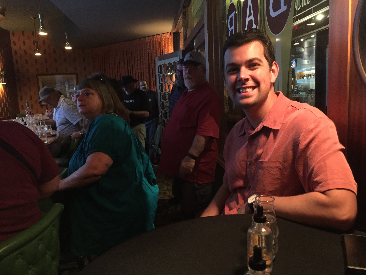

In [ ]:
def get_array(label):
    for x,y in zip(X,labels):
        if y == label: 
            return x
        
def lookup_array(array,_df):
    for i in _df.itertuples():
        for j in i.encodings:
            if np.all(j == array):
                print(i.path)
                return i.path

def showCv(cv):
    rgb = cv2.cvtColor(cv,cv2.COLOR_BGR2RGB)
    display(PIL.Image.fromarray(rgb))


for l in range(max(labels)+1)[:1]:  # limit output, redacting
    print(f'label {l}')
    thread_first(
        get_array(l),
        (lookup_array,df),
        resize,
        showCv
    )
    # show(lookup_array(df,get_array(l)))

#ok i see a few more here i can label